
# Branch Cuts Demo Notebook

This notebook introduces **branch points** and **branch cuts** in complex analysis, explains why they matter computationally, and demonstrates symbolic and numeric branch-cut computations using the `branchcuts` package.

## Contents

1. Conceptual introduction
2. Why branch cuts matter in computation
3. Setup
4. 2D visualization: the principal branch cut of $\log z$
5. 2D visualization: the principal branch cut of $\sqrt{z}$
6. 2D visualization: cuts of $\operatorname{atanh}(z)$
7. 2D visualization: argument coloring for $\log z$
8. 3D visualization: the imaginary part of the principal logarithm
9. 3D visualization: the real part of the principal square root
10. 3D visualization: magnitude of the jump across the logarithm cut
11. Curved and pulled-back branch cuts
12. Basic symbolic branch cuts
13. Post-simplification
14. Numeric seam sampling
15. Restricted-expression form
16. Conclusion

## Running the notebook

From the repository root:

```bash
pip install -e .
jupyter lab
```


If you want to run the notebook without installing the package:

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print("Project root:", ROOT)
print("Using src path:", SRC)
print("Package expected at:", SRC / "branchcuts")


## 1. Introduction: branch points and branch cuts

Many complex functions are naturally **multivalued**. A basic example is the logarithm:

$$
\log z = \log|z| + i(\arg z + 2\pi k), \qquad k \in \mathbb{Z}.
$$

Because the complex argument is only defined modulo $2\pi$, the logarithm has infinitely many values unless one chooses a single branch. The same phenomenon appears in functions such as

- $z^\alpha$ for non-integer $\alpha$,
- $\sqrt{z}$,
- inverse trigonometric and inverse hyperbolic functions,
- many special functions obtained through analytic continuation.

A **branch point** is a point around which analytic continuation changes the value of the function after a loop. For example:

- $z=0$ is a branch point of $\log z$ and $\sqrt{z}$,
- $z=\infty$ is also a branch point for $\log z$,
- $z=\pm 1$ are branch points for several inverse trigonometric functions.

To work with a single-valued version of a multivalued function, one introduces a **branch cut**: a curve or set removed from the complex plane so that the function becomes single-valued on the remaining domain.

For the principal branches:

- $\log z$ usually has a cut on the negative real axis,
- $\sqrt{z}$ usually has a cut on the negative real axis,
- $\operatorname{atanh}(z)$ has cuts on $(-\infty,-1]$ and $[1,\infty)$.

The cut is not unique. Different conventions are possible; the important thing is consistency.



## 2. Why branch cuts matter in computation

Branch cuts are not just a theoretical curiosity. They matter in:

### Symbolic computation
A symbolic system must know where identities are valid. For example, naive rules such as
$$
\sqrt{z^2} = z
$$
are not globally correct on $\mathbb{C}$.

### Numerical evaluation
Values can differ sharply on opposite sides of a cut. When a numerical algorithm crosses a cut accidentally, it may appear to “jump.”

### Differential equations and special functions
Many special functions are defined by analytic continuation. Their numerical stability, asymptotics, and continuation formulas depend on branch conventions.

### Scientific applications
Branch-aware computation appears in:
- wave propagation and scattering,
- potential theory,
- conformal mapping,
- asymptotic analysis,
- contour integration,
- quantum mechanics and complex dispersion relations,
- special-function evaluation in applied mathematics.

A central computational object is the **jump** across a cut:
$$
\operatorname{Jump}(f; z_0)
=
\lim_{\varepsilon\to 0^+} f(z_0 + i\varepsilon) - f(z_0 - i\varepsilon).
$$

For the principal logarithm on the negative real axis,
$$
\operatorname{Jump}(\log z; x) = 2\pi i \qquad (x<0,\ x\in\mathbb{R}).
$$


## 3. Setup

In [38]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

from sympy import symbols, log, sqrt, acos, asin, atanh, asec, acsc
from branchcuts import *

z = symbols('z', complex=True)
z

z


## 4. 2D visualization: the principal branch cut of $\log z$

The principal logarithm is discontinuous when crossing the negative real axis. In the plot below, the cut is highlighted and the branch point at $0$ is marked.


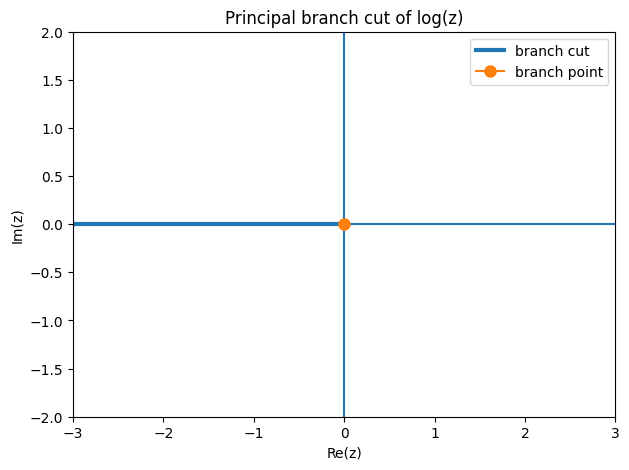

In [4]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.axhline(0)
ax.axvline(0)
ax.plot(np.linspace(-3, 0, 200), np.zeros(200), linewidth=3, label='branch cut')
ax.plot([0], [0], marker='o', markersize=8, label='branch point')
ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title('Principal branch cut of log(z)')
ax.legend()
plt.show()


## 5. 2D visualization: the principal branch cut of $\sqrt{z}$

The principal square root also has a branch point at $0$ and a standard cut on the negative real axis.


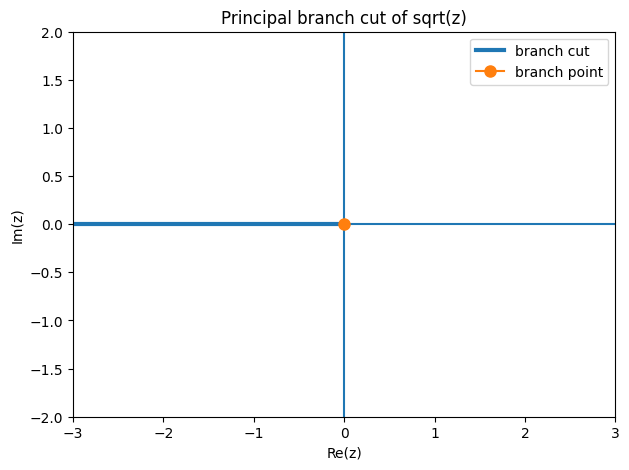

In [5]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.axhline(0)
ax.axvline(0)
ax.plot(np.linspace(-3, 0, 200), np.zeros(200), linewidth=3, label='branch cut')
ax.plot([0], [0], marker='o', markersize=8, label='branch point')
ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title('Principal branch cut of sqrt(z)')
ax.legend()
plt.show()


## 6. 2D visualization: cuts of $\operatorname{atanh}(z)$

For the principal branch of $\operatorname{atanh}(z)$, the standard cuts lie on the real axis outside the interval $[-1,1]$.


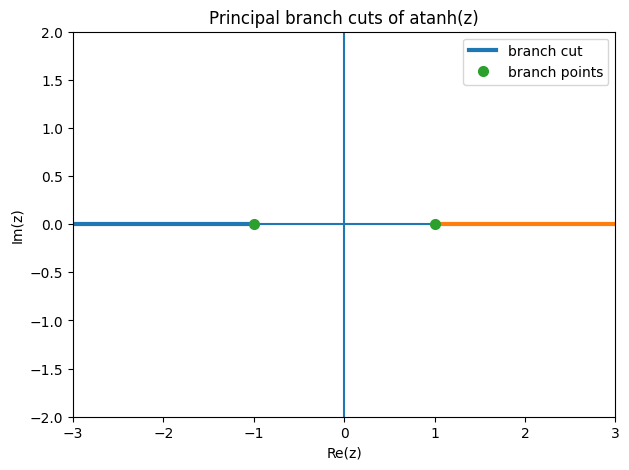

In [6]:
fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111)
ax.axhline(0)
ax.axvline(0)
ax.plot(np.linspace(-3, -1, 200), np.zeros(200), linewidth=3, label='branch cut')
ax.plot(np.linspace(1, 3, 200), np.zeros(200), linewidth=3)
ax.plot([-1, 1], [0, 0], linestyle='None', marker='o', markersize=7, label='branch points')
ax.set_xlim(-3, 3)
ax.set_ylim(-2, 2)
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title('Principal branch cuts of atanh(z)')
ax.legend()
plt.show()


## 7. 2D visualization: argument coloring for $\log z$

A branch cut can also be understood through the discontinuity of the argument. The next plot shows the principal argument $\arg(z)\in(-\pi,\pi]$, which jumps across the negative real axis.


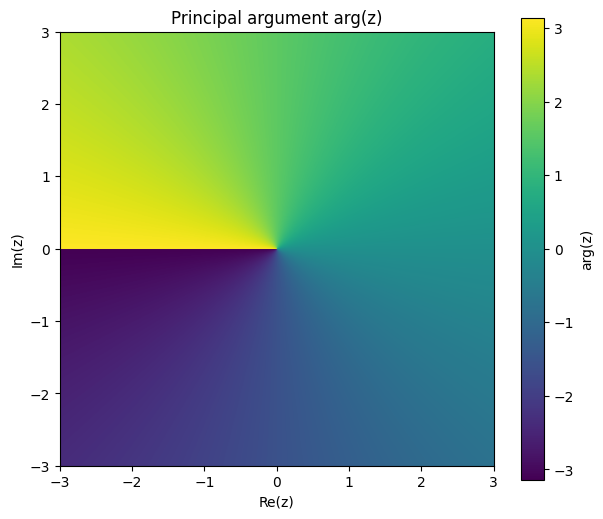

In [7]:
x = np.linspace(-3, 3, 500)
y = np.linspace(-3, 3, 500)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
Arg = np.angle(Z)
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111)
im = ax.imshow(Arg, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', aspect='equal')
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_title('Principal argument arg(z)')
fig.colorbar(im, ax=ax, label='arg(z)')
plt.show()


## 8. 3D visualization: the imaginary part of the principal logarithm

For the principal logarithm,
$$
\log z = \log|z| + i\arg(z),
$$
so the imaginary part is the principal argument. The jump across the cut appears as a vertical discontinuity.


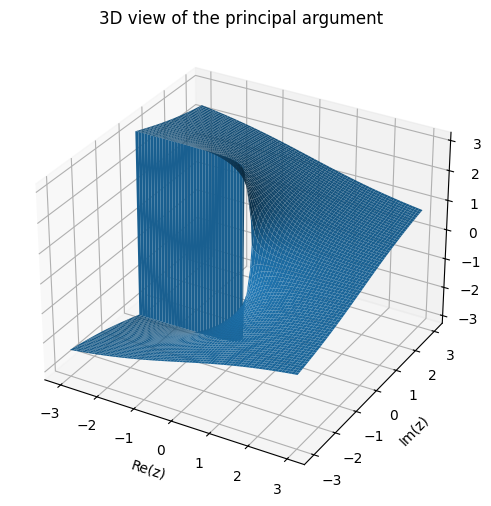

In [8]:
x = np.linspace(-3, 3, 220)
y = np.linspace(-3, 3, 220)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
Arg = np.angle(Z)
mask = np.abs(Z) < 0.1
Arg = np.where(mask, np.nan, Arg)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Arg, rstride=3, cstride=3, linewidth=0, antialiased=True)
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_zlabel('Im(log(z))')
ax.set_title('3D view of the principal argument')
plt.show()


## 9. 3D visualization: the real part of the principal square root

The real part of $\sqrt{z}$ on the principal branch is continuous away from the cut, but the branch structure is still visible near the negative real axis and the branch point at $0$.


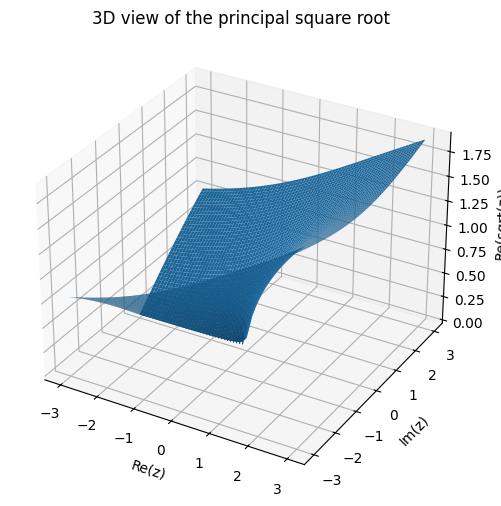

In [9]:
x = np.linspace(-3, 3, 220)
y = np.linspace(-3, 3, 220)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y
W = np.sqrt(Z)
U = np.real(W)
mask = np.abs(Z) < 0.05
U = np.where(mask, np.nan, U)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, U, rstride=3, cstride=3, linewidth=0, antialiased=True)
ax.set_xlabel('Re(z)')
ax.set_ylabel('Im(z)')
ax.set_zlabel('Re(sqrt(z))')
ax.set_title('3D view of the principal square root')
plt.show()


## 10. 3D visualization: magnitude of the jump across the logarithm cut

A direct way to visualize a jump is to evaluate
$$
\left| \log(x+i\varepsilon) - \log(x-i\varepsilon) \right|
$$
for small $\varepsilon$. Along the negative real axis, this approaches $2\pi$.


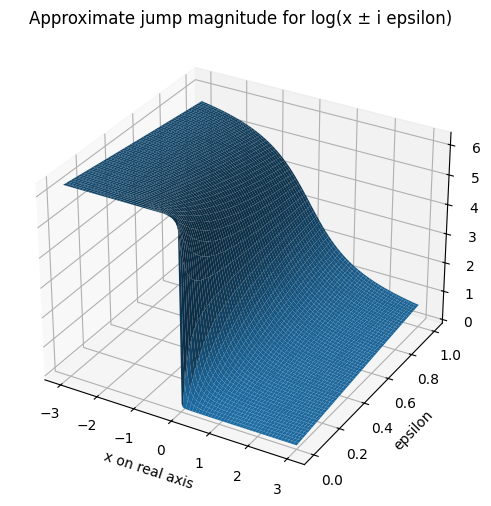

In [10]:
x = np.linspace(-3, 3, 220)
eps = np.linspace(1e-3, 1.0, 180)
X, E = np.meshgrid(x, eps)
F_plus = np.log(X + 1j * E)
F_minus = np.log(X - 1j * E)
J = np.abs(F_plus - F_minus)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, E, J, rstride=3, cstride=3, linewidth=0, antialiased=True)
ax.set_xlabel('x on real axis')
ax.set_ylabel('epsilon')
ax.set_zlabel('|jump|')
ax.set_title('Approximate jump magnitude for log(x ± i epsilon)')
plt.show()


## 11. Curved and pulled-back branch cuts

Many interesting branch cuts are **not straight lines** in the $z$-plane. A standard way this happens is through composition.

If a principal branch has a cut on some set $C$ in the inner variable $w$, then a composed function such as
$$
f(g(z))
$$
has a cut on the **preimage**
$$
g^{-1}(C).
$$

For example, the principal logarithm has its cut on the negative real axis in the $w$-plane, so
$$
\log(g(z))
$$
has a cut wherever
$$
\Im(g(z)) = 0, \qquad \Re(g(z)) \le 0.
$$

This section visualizes several such examples. The goal is not only to see the cut itself, but also to see how nonlinear maps bend, split, and replicate standard cuts.



### Helper plotting functions

The next utilities plot:
- a Boolean seam mask for $\Im(g(z)) \approx 0$ and $\Re(g(z)) \le 0$,
- an argument heatmap for $g(z)$,
- a 3D approximate jump magnitude for $\log(g(z))$ along vertical perturbations.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def seam_mask_from_inner(gfun, xlim=(-3,3), ylim=(-3,3), n=700, tol=0.03):
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    W = gfun(Z)
    mask = (np.abs(np.imag(W)) < tol) & (np.real(W) <= 0)
    return x, y, X, Y, Z, W, mask

def plot_seam_and_arg(gfun, title, xlim=(-3,3), ylim=(-3,3), n=600, tol=0.03):
    x, y, X, Y, Z, W, mask = seam_mask_from_inner(gfun, xlim=xlim, ylim=ylim, n=n, tol=tol)
    Arg = np.angle(W)

    fig = plt.figure(figsize=(13, 5))

    ax1 = fig.add_subplot(121)
    ax1.imshow(mask.astype(float), extent=[x.min(), x.max(), y.min(), y.max()],
               origin='lower', aspect='equal')
    ax1.set_xlabel('Re(z)')
    ax1.set_ylabel('Im(z)')
    ax1.set_title(f'Seam mask for {title}')

    ax2 = fig.add_subplot(122)
    im = ax2.imshow(Arg, extent=[x.min(), x.max(), y.min(), y.max()],
                    origin='lower', aspect='equal')
    ax2.set_xlabel('Re(z)')
    ax2.set_ylabel('Im(z)')
    ax2.set_title(f'arg(inner map) for {title}')
    fig.colorbar(im, ax=ax2, label='arg')

    plt.show()

def plot_log_jump_magnitude_from_inner(gfun, title, xlim=(-3,3), ylim=(-3,3), n=220, eps=1e-3):
    x = np.linspace(xlim[0], xlim[1], n)
    y = np.linspace(ylim[0], ylim[1], n)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    Wp = gfun(Z + 1j*eps)
    Wm = gfun(Z - 1j*eps)

    # Avoid points too close to singularities of the inner map by masking non-finite values
    with np.errstate(divide='ignore', invalid='ignore'):
        Fp = np.log(Wp)
        Fm = np.log(Wm)
        J = np.abs(Fp - Fm)

    J = np.where(np.isfinite(J), J, np.nan)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, J, rstride=3, cstride=3, linewidth=0, antialiased=True)
    ax.set_xlabel('Re(z)')
    ax.set_ylabel('Im(z)')
    ax.set_zlabel('|jump|')
    ax.set_title(f'Approximate jump magnitude for log(inner) : {title}')
    plt.show()



### Example A: $\log(z^2 + i z)$

This is a good first example because the preimage of the negative real axis under
$$
g(z)=z^2+i z
$$
is not just a standard coordinate-axis cut. The geometry is inherited from a nonlinear quadratic map.


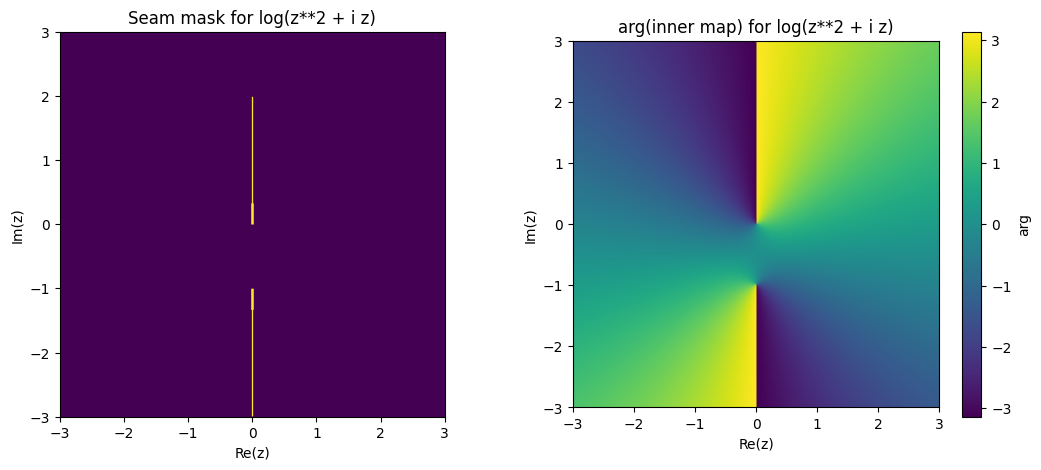

In [ ]:
g1 = lambda Z: Z**2 + 1j*Z
plot_seam_and_arg(g1, 'log(z**2 + i z)', xlim=(-3,3), ylim=(-3,3), n=600, tol=0.025)

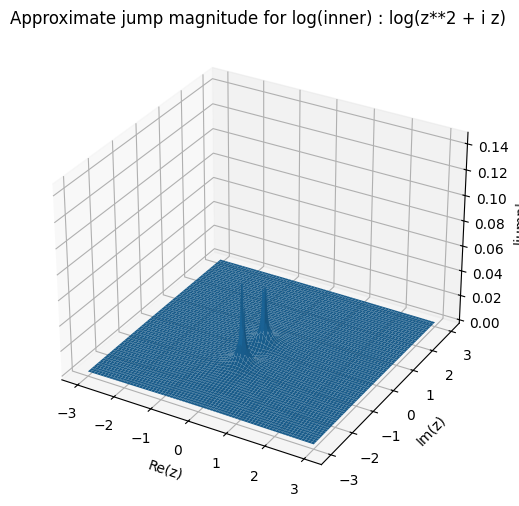

In [ ]:
plot_log_jump_magnitude_from_inner(g1, 'log(z**2 + i z)', xlim=(-3,3), ylim=(-3,3), n=220, eps=1e-3)


### Example B: $\sqrt{1 - z^3}$

The principal square root has a cut on the negative real axis of its argument. For
$$
\sqrt{1-z^3},
$$
the pulled-back seam is determined by where
$$
1-z^3 \in (-\infty,0].
$$

This gives a multi-ray structure associated with the cubic geometry.


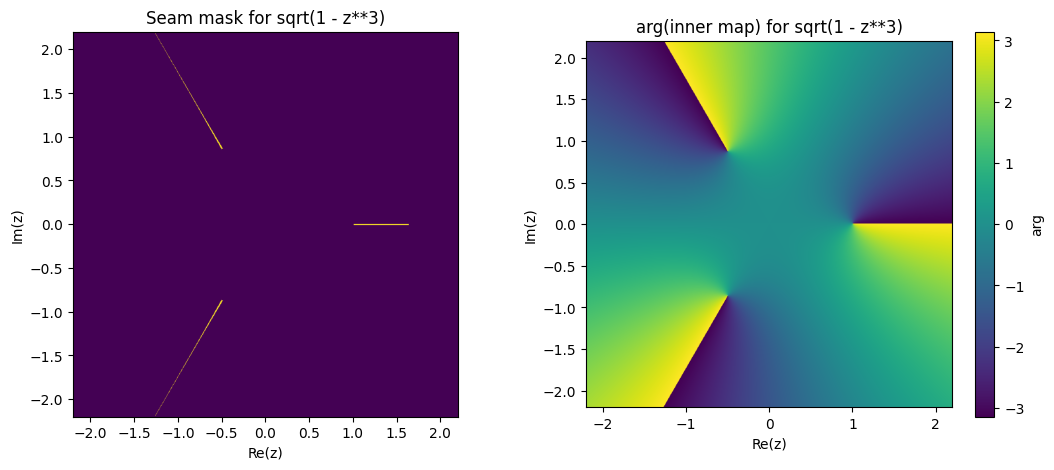

In [ ]:
g2 = lambda Z: 1 - Z**3
plot_seam_and_arg(g2, 'sqrt(1 - z**3)', xlim=(-2.2,2.2), ylim=(-2.2,2.2), n=700, tol=0.025)

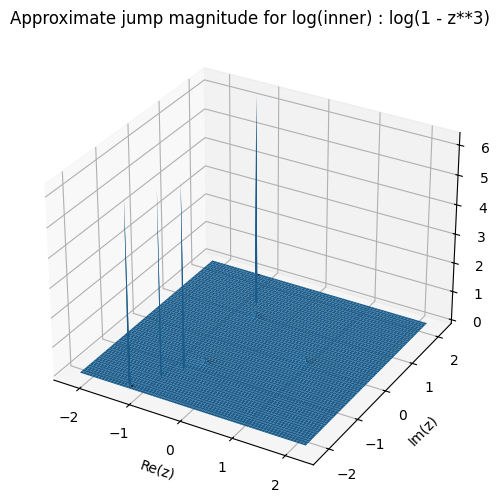

In [ ]:
plot_log_jump_magnitude_from_inner(g2, 'log(1 - z**3)', xlim=(-2.2,2.2), ylim=(-2.2,2.2), n=220, eps=1e-3)


### Example C: $\log(\sin z)$

This is an example with a **transcendental** inner map:
$$
g(z)=\sin z.
$$

Its branch geometry is much richer: the preimage of the negative real axis consists of infinitely many seam components in the complex plane.


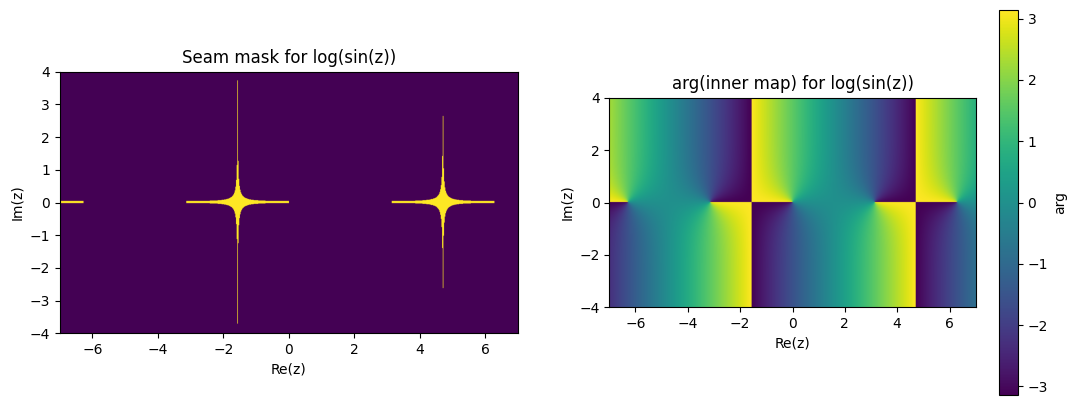

In [ ]:
g3 = lambda Z: np.sin(Z)
plot_seam_and_arg(g3, 'log(sin(z))', xlim=(-7,7), ylim=(-4,4), n=700, tol=0.03)

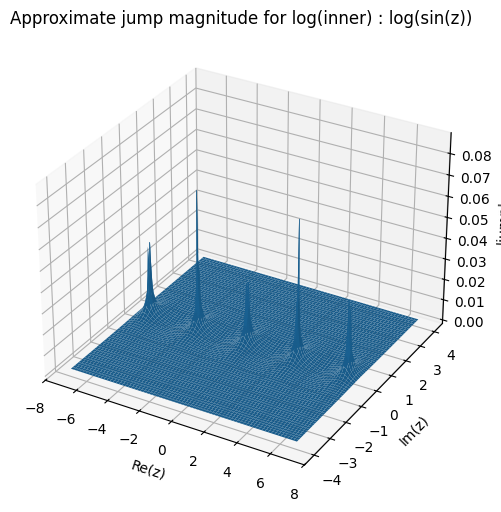

In [ ]:
plot_log_jump_magnitude_from_inner(g3, 'log(sin(z))', xlim=(-7,7), ylim=(-4,4), n=220, eps=1e-3)


### Example D: nested structure for $\sqrt{\log(1-z)}$

This example is especially relevant to the project because it combines two branch mechanisms:

1. the inner logarithm changes across the preimage of the negative real axis under $1-z$,
2. the outer square root adds a second layer of branching depending on where $\log(1-z)$ itself lands on its cut.

The seam plot below visualizes the outer condition approximately through the argument structure of $\log(1-z)$.


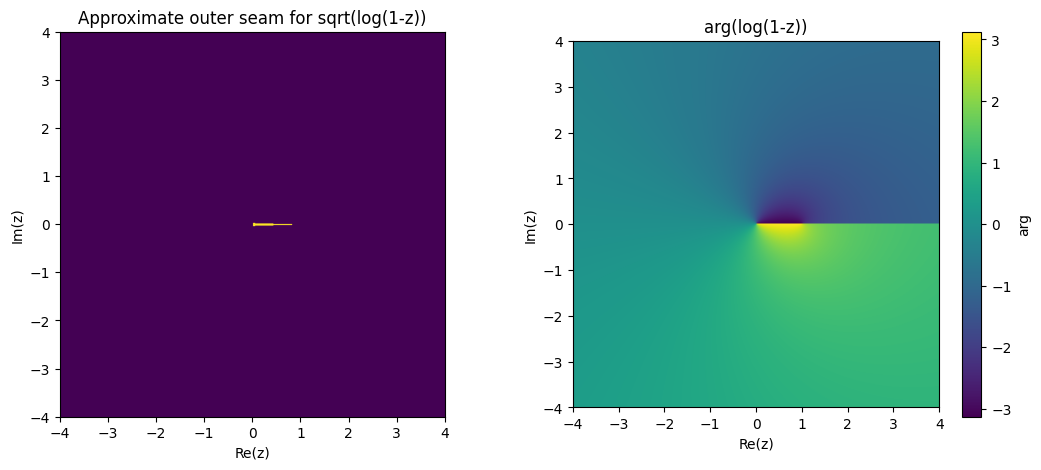

In [ ]:
x = np.linspace(-4, 4, 700)
y = np.linspace(-4, 4, 700)
X, Y = np.meshgrid(x, y)
Z = X + 1j * Y

with np.errstate(divide='ignore', invalid='ignore'):
    L = np.log(1 - Z)

outer_mask = (np.abs(np.imag(L)) < 0.03) & (np.real(L) <= 0)
ArgL = np.angle(L)

fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121)
ax1.imshow(outer_mask.astype(float), extent=[x.min(), x.max(), y.min(), y.max()],
           origin='lower', aspect='equal')
ax1.set_xlabel('Re(z)')
ax1.set_ylabel('Im(z)')
ax1.set_title('Approximate outer seam for sqrt(log(1-z))')

ax2 = fig.add_subplot(122)
im = ax2.imshow(ArgL, extent=[x.min(), x.max(), y.min(), y.max()],
                origin='lower', aspect='equal')
ax2.set_xlabel('Re(z)')
ax2.set_ylabel('Im(z)')
ax2.set_title('arg(log(1-z))')
fig.colorbar(im, ax=ax2, label='arg')
plt.show()


### Interpretation

These examples illustrate three important principles:

- **Pulled-back cuts:** a simple cut in the inner variable can become a complicated locus in the outer variable.
- **Replication under nonlinear maps:** polynomial maps can split a single cut into multiple components or rays.
- **Nested branching:** compositions such as $\sqrt{\log(1-z)}$ inherit more than one source of discontinuity.

This is exactly why a branch-cut engine benefits from both:
- symbolic condition propagation, and
- numeric seam sampling.


## 12. Basic symbolic branch cuts

In [11]:
branch_cut_jumps(log(z), z, mode="piecewise")

{'Plus': (Piecewise((log(-z) + I*pi, Contains(z, Reals) & (z < 0)), (Undefined(), True)),
  Piecewise((log(z), ~(Contains(z, Reals) & (z < 0))), (Undefined(), True))),
 'Minus': (Piecewise((log(-z) - I*pi, Contains(z, Reals) & (z < 0)), (Undefined(), True)),
  Piecewise((log(z), ~(Contains(z, Reals) & (z < 0))), (Undefined(), True))),
 'Jump': (Piecewise((2*I*pi, Contains(z, Reals) & (z < 0)), (0, True)), 0, 0)}

In [12]:
branch_cut_jumps(sqrt(z), z, mode="piecewise")

{'Plus': (Piecewise((I*sqrt(-z), Contains(z, Reals) & (z < 0)), (Undefined(), True)),
  Piecewise((sqrt(z), ~(Contains(z, Reals) & (z < 0))), (Undefined(), True))),
 'Minus': (Piecewise((-I*sqrt(-z), Contains(z, Reals) & (z < 0)), (Undefined(), True)),
  Piecewise((sqrt(z), ~(Contains(z, Reals) & (z < 0))), (Undefined(), True))),
 'Jump': (Piecewise((2*I*sqrt(-z), Contains(z, Reals) & (z < 0)), (0, True)),
  0,
  0)}

In [13]:
branch_cut_jumps(acos(z), z, mode="piecewise")

{'Plus': (acos(z),),
 'Minus': (acos(z),),
 'Jump': (Piecewise((2*I*acosh(z), Contains(z, Reals) & (z > 1)), (0, True)),
  Piecewise((-2*I*acosh(-z), Contains(z, Reals) & (z < -1)), (0, True)),
  0)}

In [14]:
branch_cut_jumps(asin(z), z, mode="piecewise")

{'Plus': (asin(z),),
 'Minus': (asin(z),),
 'Jump': (Piecewise((-2*I*acosh(z), Contains(z, Reals) & (z > 1)), (0, True)),
  Piecewise((2*I*acosh(-z), Contains(z, Reals) & (z < -1)), (0, True)),
  0)}

In [15]:
branch_cut_jumps(atanh(z), z, mode="piecewise")

{'Plus': (atanh(z),),
 'Minus': (atanh(z),),
 'Jump': (Piecewise((-I*pi, Contains(z, Reals) & (z > 1)), (0, True)),
  Piecewise((I*pi, Contains(z, Reals) & (z < -1)), (0, True)),
  0)}

In [16]:
expr = sqrt(log(1 - z))
expr

sqrt(log(1 - z))

In [17]:
branch_cut_jumps(expr, z, mode="pairs")

{'Plus': [(I*sqrt(-log(z - 1) - I*pi),
   (z > 1) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0)),
  (I*sqrt(-log(1 - z)),
   Contains(log(1 - z), Reals) & (log(1 - z) < 0) & ~(Contains(1 - z, Reals) & (1 - z < 0))),
  (sqrt(log(z - 1) + I*pi),
   (z > 1) & Contains(1 - z, Reals) & ~(Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0))),
  (sqrt(log(1 - z)),
   ~(Contains(1 - z, Reals) & (1 - z < 0)) & ~(Contains(log(1 - z), Reals) & (log(1 - z) < 0)))],
 'Minus': [(-I*sqrt(-log(z - 1) + I*pi),
   (z > 1) & Contains(1 - z, Reals) & Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0)),
  (-I*sqrt(-log(1 - z)),
   Contains(log(1 - z), Reals) & (log(1 - z) < 0) & ~(Contains(1 - z, Reals) & (1 - z < 0))),
  (sqrt(log(z - 1) - I*pi),
   (z > 1) & Contains(1 - z, Reals) & ~(Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0))),
  (sqrt(log(1 - z)),
   ~(Contains(1 - z, Reals) & (1 - z < 0)) & ~(Contains(log(1 - z), Reals) & 

## 13. Post-simplification

In [18]:
pairs = branch_cut_jumps(expr, z, mode="pairs")
pairs["Jump"]

[(I*(sqrt(-log(z - 1) - I*pi) + sqrt(-log(z - 1) + I*pi)),
  (z > 1) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0)),
 (I*(sqrt(-log(1 - z)) + sqrt(-log(z - 1) - I*pi)),
  (z > 1) & Contains(1 - z, Reals) & Contains(log(1 - z), Reals) & (log(1 - z) < 0) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(1 - z, Reals) & (1 - z < 0))),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(z - 1) - I*pi),
  (z > 1) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0))),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(1 - z)),
  (z > 1) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(1 - z, Reals) & (1 - z < 0)) & ~(Contains(log(1 - z), Reals) & (log(1 - z) < 0))),
 (I*(sqrt(-log(1 - z)) + sqrt(-log(z - 1) + I*pi)),
  (z > 1) & Contai

In [19]:
post_simplify_pairs(pairs["Jump"], z)

[(I*(sqrt(-log(1 - z)) + sqrt(-log(z - 1) - I*pi)),
  Contains(z, Reals) & (z > 1) & Contains(log(1 - z), Reals) & (log(1 - z) < 0) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0)),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(z - 1) - I*pi),
  Contains(z, Reals) & (z > 1) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0))),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(1 - z)),
  Contains(z, Reals) & (z > 1) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(log(1 - z), Reals) & (log(1 - z) < 0))),
 (I*(sqrt(-log(1 - z)) + sqrt(-log(z - 1) + I*pi)),
  Contains(z, Reals) & (z > 1) & Contains(log(1 - z), Reals) & (log(1 - z) < 0) & Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0)),
 (2*I*sqrt(-log(1 - z)), Contains(z, Reals) & (z >= 0) & (log(1 - z) < 0)),
 (I*sqrt(-log(1 - z)) - sqrt(log(z - 1) - I*pi),
  Contains(z, Reals) & (z > 1) & Contains(log(1 - z), Reals) & (lo

In [20]:
expr2 = asec(1 - z) + acsc(2*z) + sqrt(log(1 - z))
expr2

sqrt(log(1 - z)) + acsc(2*z) + asec(1 - z)

In [21]:
raw = branch_cut_jumps(expr2, z, mode="pairs")
raw["Jump"]

[(I*(sqrt(-log(z - 1) - I*pi) + sqrt(-log(z - 1) + I*pi) - 2*acosh(1/(2*z)) + 2*acosh(-1/(z - 1))),
  (z > 0) & (z > 1) & (z < 1/2) & (z < 1) & Contains(2*z, Reals) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0)),
 (I*(sqrt(-log(z - 1) - I*pi) + sqrt(-log(z - 1) + I*pi) - 2*acosh(1/(2*z)) - 2*acosh(1/(z - 1))),
  (z > 0) & (z > 1) & (z < 1/2) & (z < 2) & Contains(2*z, Reals) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0)),
 (I*(sqrt(-log(z - 1) - I*pi) + sqrt(-log(z - 1) + I*pi) - 2*acosh(1/(2*z))),
  (z > 0) & (z > 1) & (z < 1/2) & Contains(2*z, Reals) & Contains(1 - z, Reals) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0)),
 (I*(sqrt(-log(z - 1) - I*pi) + sqrt(-log(z - 1) + I*pi) + 2*acosh(-1/(2*z)) + 

In [22]:
post_simplify_pairs(raw["Jump"], z)

[(I*(sqrt(-log(1 - z)) + sqrt(-log(z - 1) - I*pi) - 2*asech(z - 1)),
  Contains(z, Reals) & (z > 1) & (z < 2) & Contains(log(1 - z), Reals) & (log(1 - z) < 0) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0)),
 (I*(sqrt(-log(1 - z)) + sqrt(-log(z - 1) - I*pi)),
  Contains(z, Reals) & (z > 1) & Contains(log(1 - z), Reals) & (log(1 - z) < 0) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0)),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(z - 1) - I*pi) - 2*I*asech(z - 1),
  Contains(z, Reals) & (z > 1) & (z < 2) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0))),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(z - 1) - I*pi),
  Contains(z, Reals) & (z > 1) & Contains(log(z - 1) + I*pi, Reals) & (log(z - 1) + I*pi < 0) & ~(Contains(log(z - 1) - I*pi, Reals) & (log(z - 1) - I*pi < 0))),
 (I*sqrt(-log(z - 1) - I*pi) - sqrt(log(1 - z)) - 2*I*asech(z - 1),
  Contains(z, Reals) & (z > 1) & (z < 2) & Con

## 14. Numeric seam sampling

In [23]:
numeric_branch_cut_jumps(log(z), [z])

[{'BranchCondition': Contains(z, Reals) & (z < 0),
  'SamplePoint': -2,
  'Normal': I,
  'fPlus': 0.693147180559945286226763982995 + 3.14159264858979314638531832315*I,
  'fMinus': 0.693147180559945286226763982995 - 3.14159264858979314638531832315*I,
  'Jump': 6.28318529717958629277063664631*I,
  'ExpectedJump': 6.28318530717958647692528676656*I}]

In [24]:
numeric_branch_cut_jumps(sqrt(z), [z])

[{'BranchCondition': Contains(z, Reals) & (z < 0),
  'SamplePoint': -2,
  'Normal': I,
  'fPlus': 3.535533905932737684928e-9 + 1.41421356237309505322110610663*I,
  'fMinus': 3.535533905932737684928e-9 - 1.41421356237309505322110610663*I,
  'Jump': 2.82842712474619010644221221325*I,
  'ExpectedJump': 2.82842712474619009760337744842*I}]

## 15. Restricted-expression form

In [37]:
from sympy import symbols, log, sqrt, S
from sympy.sets.contains import Contains

z = symbols("z", complex=True)

post_simplify_pairs(branch_cut_jumps(
    RestrictedExpr(log(z), Contains(z, S.Reals) & (z > 0)),
    z, mode="pairs"
)["Jump"], z)

[(0, True)]

In [27]:
post_simplify_pairs(branch_cut_jumps(
    RestrictedExpr(sqrt(log(1 - z)), Contains(z, S.Reals) & (z < 1)),
    z, mode="pairs"
)["Jump"], z)

[(2*I*sqrt(-log(1 - z)),
  Contains(z, Reals) & (z >= 0) & (z < 1) & Contains(log(1 - z), Reals) & (log(1 - z) < 0)),
 (0, True)]


## 16. Summary

This notebook introduced:

- branch points as obstructions to single-valued continuation,
- branch cuts as choices used to define principal branches,
- jump discontinuities as computable boundary differences,
- 2D and 3D visualizations of standard branches,
- symbolic and numeric branch-cut computation in the package.

For more examples and implementation details, see the `docs/` and `examples/` directories in the repository.
